# Wildire Risk to 100 Locations Across United States

This notebook samples Open Climate Risk data at 100 predefined locations and compares
present-day (`rps_2011`) and future (`rps_2047`) annual wildfire risk.

**What this walkthrough does:**
1. Loads the OCR fire-risk raster
2. Samples values at 100 point locations with nearest-neighbor lookup
3. Computes wildfire risk in percent, categorical risk score, and ranking
4. Visualizes percent risk, score, and rank on three-panel maps (current, future, difference)

In [1]:
import geopandas as gpd
import icechunk
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from ocr.risks.fire import rps_to_score

In [2]:
# Configure S3 storage for the Icechunk repository
version = 'v1.1.0'
storage = icechunk.s3_storage(
    bucket='us-west-2.opendata.source.coop',
    prefix=f'carbonplan/carbonplan-ocr/output/fire-risk/tensor/production/{version}/ocr.icechunk',
    region='us-west-2',
    anonymous=True,
)

# Open the repository and create a read-only session on main
repo = icechunk.Repository.open(storage)
session = repo.readonly_session('main')

ds = xr.open_dataset(session.store, engine='zarr', chunks='auto')
ds

<xarray.Dataset> Size: 652GB
Dimensions:        (latitude: 97579, longitude: 208881)
Coordinates:
  * latitude       (latitude) float64 781kB 22.43 22.43 22.43 ... 52.48 52.48
  * longitude      (longitude) float64 2MB -128.4 -128.4 ... -64.05 -64.05
Data variables:
    bp_2011        (latitude, longitude) float32 82GB dask.array<chunksize=(6000, 4500), meta=np.ndarray>
    bp_2047        (latitude, longitude) float32 82GB dask.array<chunksize=(6000, 4500), meta=np.ndarray>
    crps_scott     (latitude, longitude) float32 82GB dask.array<chunksize=(6000, 4500), meta=np.ndarray>
    bp_2011_riley  (latitude, longitude) float32 82GB dask.array<chunksize=(6000, 4500), meta=np.ndarray>
    rps_2011       (latitude, longitude) float32 82GB dask.array<chunksize=(6000, 4500), meta=np.ndarray>
    rps_scott      (latitude, longitude) float32 82GB dask.array<chunksize=(6000, 4500), meta=np.ndarray>
    bp_2047_riley  (latitude, longitude) float32 82GB dask.array<chunksize=(6000, 4500), meta=np.ndarray>
    rps_2047       (latitude, longitude) float32 82GB dask.array<chunksize=(6000, 4500), meta=np.ndarray>
Attributes:
    version:          1.1.0
    provider:         CarbonPlan
    terms_of_access:  https://docs.carbonplan.org/ocr/en/latest/terms-of-data...
    data_sources:     https://docs.carbonplan.org/ocr/en/latest/reference/dat...
    license_name:     CC-BY-4.0
    license_url:      https://creativecommons.org/licenses/by/4.0/

## Load 100 target locations

These are the fixed point locations used for this demo.

In [3]:
points_df = pd.read_csv('points-locations.csv')
points_df

,label,state,lat,lon
0,al_birmingham,AL,33.5186,-86.8104
1,al_talladega_nf,AL,33.4338,-86.1058
2,ar_fort_smith,AR,35.3859,-94.3985
3,ar_monticello,AR,33.6290,-91.7909
4,az_flagstaff,AZ,35.1983,-111.6513
...,...,...,...,...
95,wi_madison,WI,43.0731,-89.4012
96,wv_charleston,WV,38.3498,-81.6326
97,wv_elkins,WV,38.9259,-79.8467
98,wy_cheyenne,WY,41.1400,-104.8202


## Build xarray point indexers

We package latitude/longitude into an xarray `Dataset` with a shared
`point_location` dimension, so one `.sel()` call can sample all points at once.

In [4]:
points = xr.Dataset(
    data_vars={
        'latitude': (
            'point_location',
            points_df['lat'].to_numpy(dtype=float),
        ),
        'longitude': (
            'point_location',
            points_df['lon'].to_numpy(dtype=float),
        ),
    },
    coords={
        'point_location': points_df['label'].to_numpy(),
        'state': ('point_location', points_df['state'].to_numpy()),
    },
)

points

<xarray.Dataset> Size: 3kB
Dimensions:         (point_location: 100)
Coordinates:
  * point_location  (point_location) object 800B 'al_birmingham' ... 'wy_casper'
    state           (point_location) object 800B 'AL' 'AL' 'AR' ... 'WY' 'WY'
Data variables:
    latitude        (point_location) float64 800B 33.52 33.43 ... 41.14 42.85
    longitude       (point_location) float64 800B -86.81 -86.11 ... -106.3

## Vectorized nearest-neighbor sampling

This selects the nearest raster cell for each location in one vectorized operation.

In [5]:
sampled = ds.sel(
    latitude=points.latitude,
    longitude=points.longitude,
    method='nearest',
)
sampled

<xarray.Dataset> Size: 6kB
Dimensions:         (point_location: 100)
Coordinates:
    latitude        (point_location) float64 800B 33.52 33.43 ... 41.14 42.85
    longitude       (point_location) float64 800B -86.81 -86.11 ... -106.3
  * point_location  (point_location) object 800B 'al_birmingham' ... 'wy_casper'
    state           (point_location) object 800B 'AL' 'AL' 'AR' ... 'WY' 'WY'
Data variables:
    bp_2011         (point_location) float32 400B dask.array<chunksize=(100,), meta=np.ndarray>
    bp_2047         (point_location) float32 400B dask.array<chunksize=(100,), meta=np.ndarray>
    crps_scott      (point_location) float32 400B dask.array<chunksize=(100,), meta=np.ndarray>
    bp_2011_riley   (point_location) float32 400B dask.array<chunksize=(100,), meta=np.ndarray>
    rps_2011        (point_location) float32 400B dask.array<chunksize=(100,), meta=np.ndarray>
    rps_scott       (point_location) float32 400B dask.array<chunksize=(100,), meta=np.ndarray>
    bp_2047_riley   (point_location) float32 400B dask.array<chunksize=(100,), meta=np.ndarray>
    rps_2047        (point_location) float32 400B dask.array<chunksize=(100,), meta=np.ndarray>
Attributes:
    version:          1.1.0
    provider:         CarbonPlan
    terms_of_access:  https://docs.carbonplan.org/ocr/en/latest/terms-of-data...
    data_sources:     https://docs.carbonplan.org/ocr/en/latest/reference/dat...
    license_name:     CC-BY-4.0
    license_url:      https://creativecommons.org/licenses/by/4.0/

## Derive annual risk %, score, and rank

Rankings are computed from **annual fire risk in percent** (not from score bins),
which removes score-based ties and gives a strict ordering from highest to lowest risk.

In [6]:
risk_df = (
    sampled[['rps_2011', 'rps_2047']]
    .to_dataframe()
    .reset_index()
    .rename(columns={'rps_2011': 'present_risk', 'rps_2047': 'future_risk'})[
        ['point_location', 'state', 'present_risk', 'future_risk']
    ]
)

# rps_2011/rps_2047 are already annual percentages.
risk_df['present_risk_pct'] = risk_df['present_risk'].astype(float)
risk_df['future_risk_pct'] = risk_df['future_risk'].astype(float)

# Keep score bins for interpretability alongside percentages.
risk_df['present_score'] = rps_to_score(risk_df['present_risk'].to_numpy())
risk_df['future_score'] = rps_to_score(risk_df['future_risk'].to_numpy())

# Deterministic strict rank from annual risk %, highest risk gets rank 1.
# method='first' breaks exact numeric ties by existing row order.
risk_df = risk_df.sort_values('point_location').reset_index(drop=True)
risk_df['present_rank'] = (
    risk_df['present_risk_pct'].rank(ascending=False, method='first').astype(int)
)
risk_df['future_rank'] = (
    risk_df['future_risk_pct'].rank(ascending=False, method='first').astype(int)
)

# Sanity check: ranks should be unique 1..N.
if not (risk_df['present_rank'].is_unique and risk_df['future_rank'].is_unique):
    raise ValueError('Expected unique ranks for both present and future.')

risk_df = risk_df.sort_values('present_rank').reset_index(drop=True)
risk_df

,point_location,state,present_risk,future_risk,present_risk_pct,future_risk_pct,present_score,future_score,present_rank,future_rank
0,ca_julian_inland,CA,1.344096,3.251619,1.344096,3.251619,9,10,1,1
1,nm_ruidoso,NM,0.473532,0.768986,0.473532,0.768986,7,8,2,2
2,ca_mariposa_sierra,CA,0.217086,0.284374,0.217086,0.284374,7,7,3,3
3,nj_pinelands,NJ,0.172656,0.116588,0.172656,0.116588,6,6,4,8
4,az_payson,AZ,0.164299,0.227646,0.164299,0.227646,6,7,5,4
...,...,...,...,...,...,...,...,...,...,...
95,wa_wenatchee,WA,0.000000,0.000000,0.000000,0.000000,0,0,96,96
96,wa_yakima,WA,0.000000,0.000000,0.000000,0.000000,0,0,97,97
97,wi_madison,WI,0.000000,0.000000,0.000000,0.000000,0,0,98,98
98,wi_wausau,WI,0.000000,0.000000,0.000000,0.000000,0,0,99,99


## Visualizations

The maps are shown in this order:
1. Annual fire risk in percent
2. Fire risk score (0-10)
3. Rank among the 100 locations

Each figure uses a dedicated colorbar row under the maps so colorbars do not overlap map content.

### Map: annual fire risk [%] across 100 locations

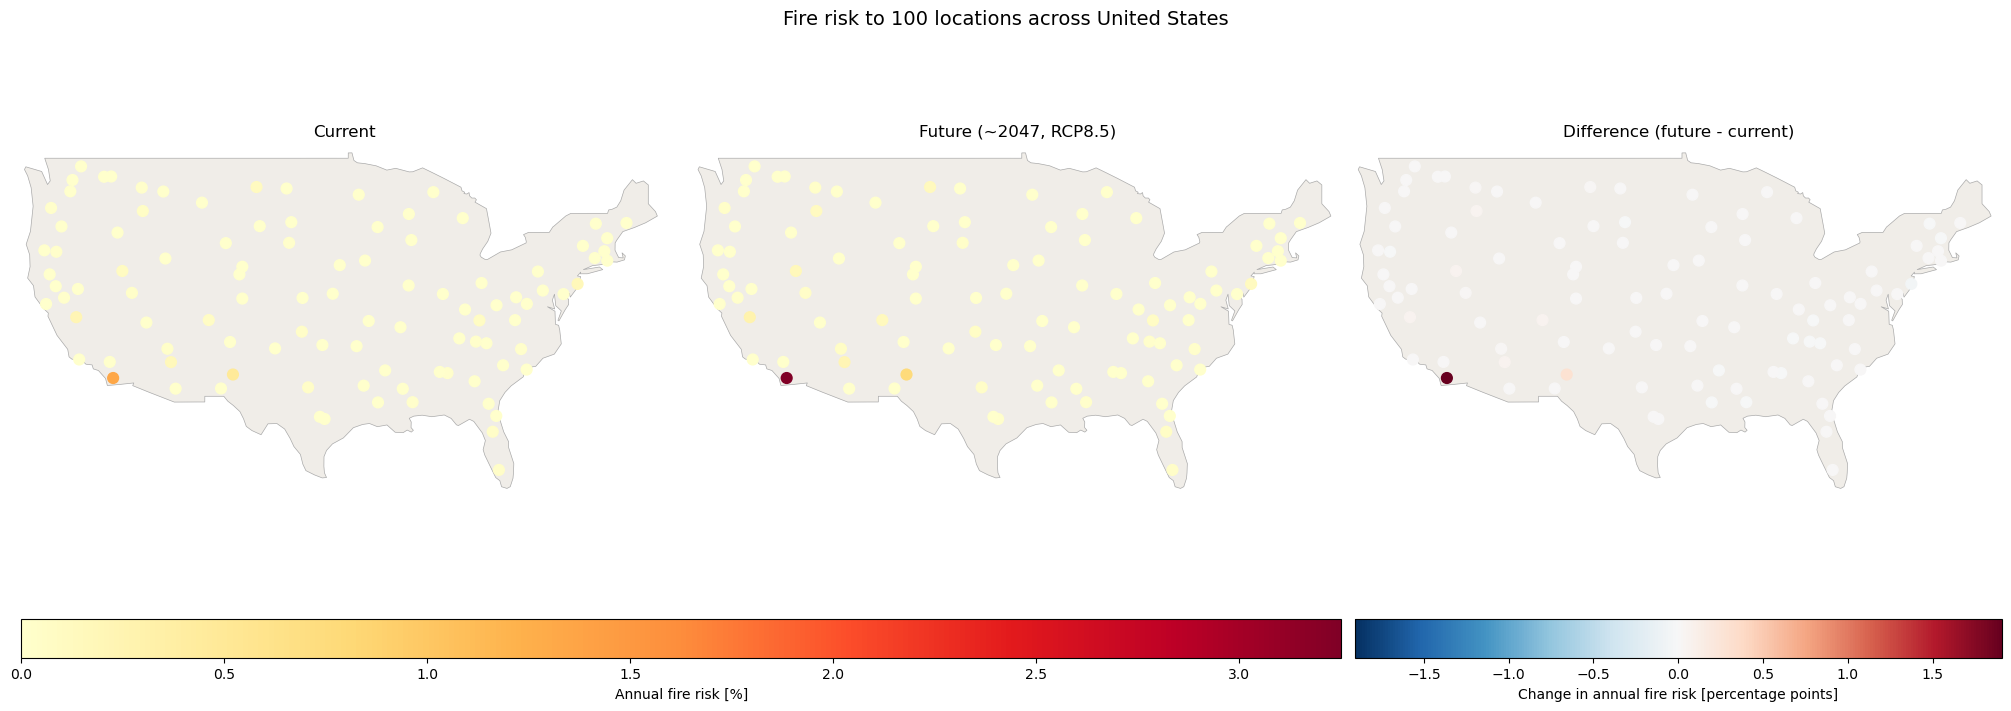

In [7]:
# Build GeoDataFrame once; reuse for all map figures.
merged = risk_df.merge(
    points_df[['label', 'lat', 'lon']], left_on='point_location', right_on='label'
)
gdf = gpd.GeoDataFrame(
    merged,
    geometry=gpd.points_from_xy(merged['lon'], merged['lat']),
    crs='EPSG:4326',
)

gdf['risk_pct_change'] = gdf['future_risk_pct'] - gdf['present_risk_pct']
gdf['score_change'] = gdf['future_score'].astype(int) - gdf['present_score'].astype(int)
gdf['rank_change'] = gdf['future_rank'] - gdf['present_rank']

# CONUS boundary from Natural Earth
ne_url = 'https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip'
world = gpd.read_file(ne_url)
conus = world[world['ISO_A3'] == 'USA']


def _two_slope_norm(values):
    diff_abs = float(np.nanmax(np.abs(values)))
    if np.isclose(diff_abs, 0.0):
        diff_abs = 1e-9
    return mcolors.TwoSlopeNorm(vmin=-diff_abs, vcenter=0.0, vmax=diff_abs)


def plot_three_panel_maps(
    gdf,
    conus,
    present_col,
    future_col,
    diff_col,
    suptitle,
    seq_cmap,
    diff_cmap,
    seq_label,
    diff_label,
    seq_vmin=None,
    seq_vmax=None,
    seq_ticks=None,
    diff_ticks=None,
):
    if seq_vmin is None:
        seq_vmin = float(min(gdf[present_col].min(), gdf[future_col].min()))
    if seq_vmax is None:
        seq_vmax = float(max(gdf[present_col].max(), gdf[future_col].max()))
    if np.isclose(seq_vmin, seq_vmax):
        seq_vmax = seq_vmin + 1e-9

    seq_norm = mcolors.Normalize(vmin=seq_vmin, vmax=seq_vmax)
    diff_norm = _two_slope_norm(gdf[diff_col].to_numpy(dtype=float))

    # Dedicated second row for colorbars prevents any overlap with the maps.
    fig = plt.figure(figsize=(20, 7), constrained_layout=True)
    gs = fig.add_gridspec(nrows=2, ncols=3, height_ratios=[18, 1.2])
    axes = [fig.add_subplot(gs[0, i]) for i in range(3)]
    cax_seq = fig.add_subplot(gs[1, 0:2])
    cax_diff = fig.add_subplot(gs[1, 2])

    panels = [
        (present_col, 'Current', seq_cmap, seq_norm),
        (future_col, 'Future (~2047, RCP8.5)', seq_cmap, seq_norm),
        (diff_col, 'Difference (future - current)', diff_cmap, diff_norm),
    ]

    for ax, (col, title, cmap, norm) in zip(axes, panels):
        conus.plot(ax=ax, color='#f0ede8', edgecolor='#aaa', linewidth=0.5)
        gdf.plot(
            ax=ax,
            column=col,
            cmap=cmap,
            norm=norm,
            markersize=60,
            legend=False,
        )
        ax.set_xlim(-125, -66)
        ax.set_ylim(24, 50)
        ax.set_title(title, fontsize=12)
        ax.set_axis_off()

    sm_seq = plt.cm.ScalarMappable(cmap=seq_cmap, norm=seq_norm)
    sm_seq.set_array([])
    cbar_seq = fig.colorbar(sm_seq, cax=cax_seq, orientation='horizontal')
    cbar_seq.set_label(seq_label)
    if seq_ticks is not None:
        cbar_seq.set_ticks(seq_ticks)

    sm_diff = plt.cm.ScalarMappable(cmap=diff_cmap, norm=diff_norm)
    sm_diff.set_array([])
    cbar_diff = fig.colorbar(sm_diff, cax=cax_diff, orientation='horizontal')
    cbar_diff.set_label(diff_label)
    if diff_ticks is not None:
        cbar_diff.set_ticks(diff_ticks)

    fig.suptitle(suptitle, fontsize=14)
    plt.show()


plot_three_panel_maps(
    gdf=gdf,
    conus=conus,
    present_col='present_risk_pct',
    future_col='future_risk_pct',
    diff_col='risk_pct_change',
    suptitle='Fire risk to 100 locations across United States',
    seq_cmap='YlOrRd',
    diff_cmap='RdBu_r',
    seq_label='Annual fire risk [%]',
    diff_label='Change in annual fire risk [percentage points]',
    seq_vmin=0.0,
)

### Map: fire risk score (0-10) across 100 locations

Score maps are shown after the percentage maps to preserve the direct probability view first.

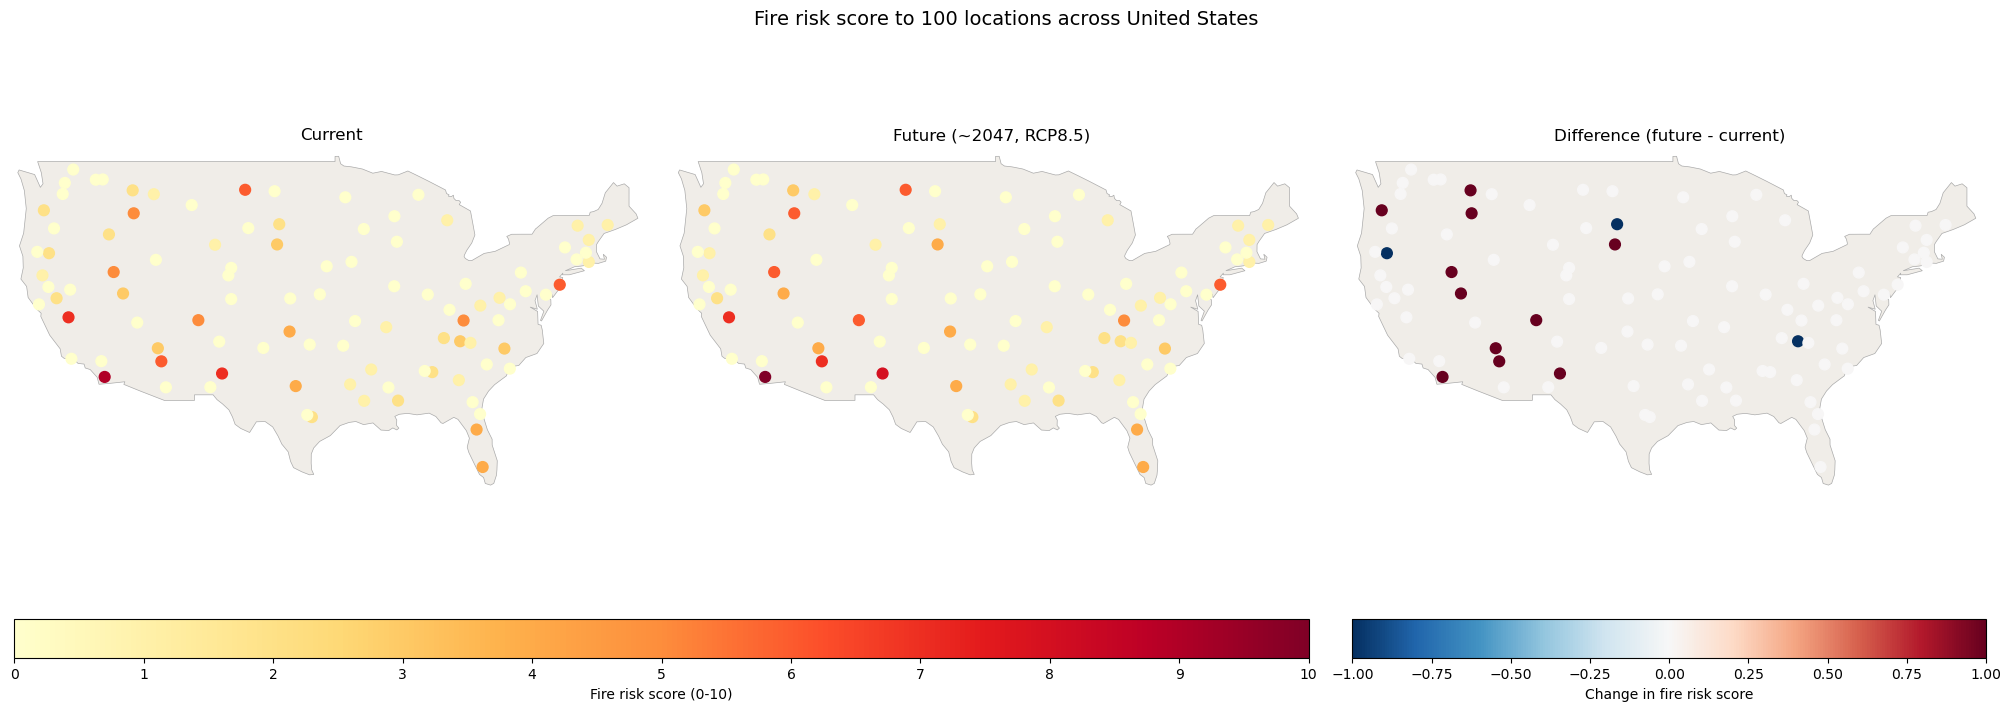

In [8]:
plot_three_panel_maps(
    gdf=gdf,
    conus=conus,
    present_col='present_score',
    future_col='future_score',
    diff_col='score_change',
    suptitle='Fire risk score to 100 locations across United States',
    seq_cmap='YlOrRd',
    diff_cmap='RdBu_r',
    seq_label='Fire risk score (0-10)',
    diff_label='Change in fire risk score',
    seq_vmin=0.0,
    seq_vmax=10.0,
    seq_ticks=np.arange(0, 11, 1),
)

### Map: fire risk rank among 100 locations

Rank is computed from annual fire risk (%) so rank 1 is always the highest annual risk.

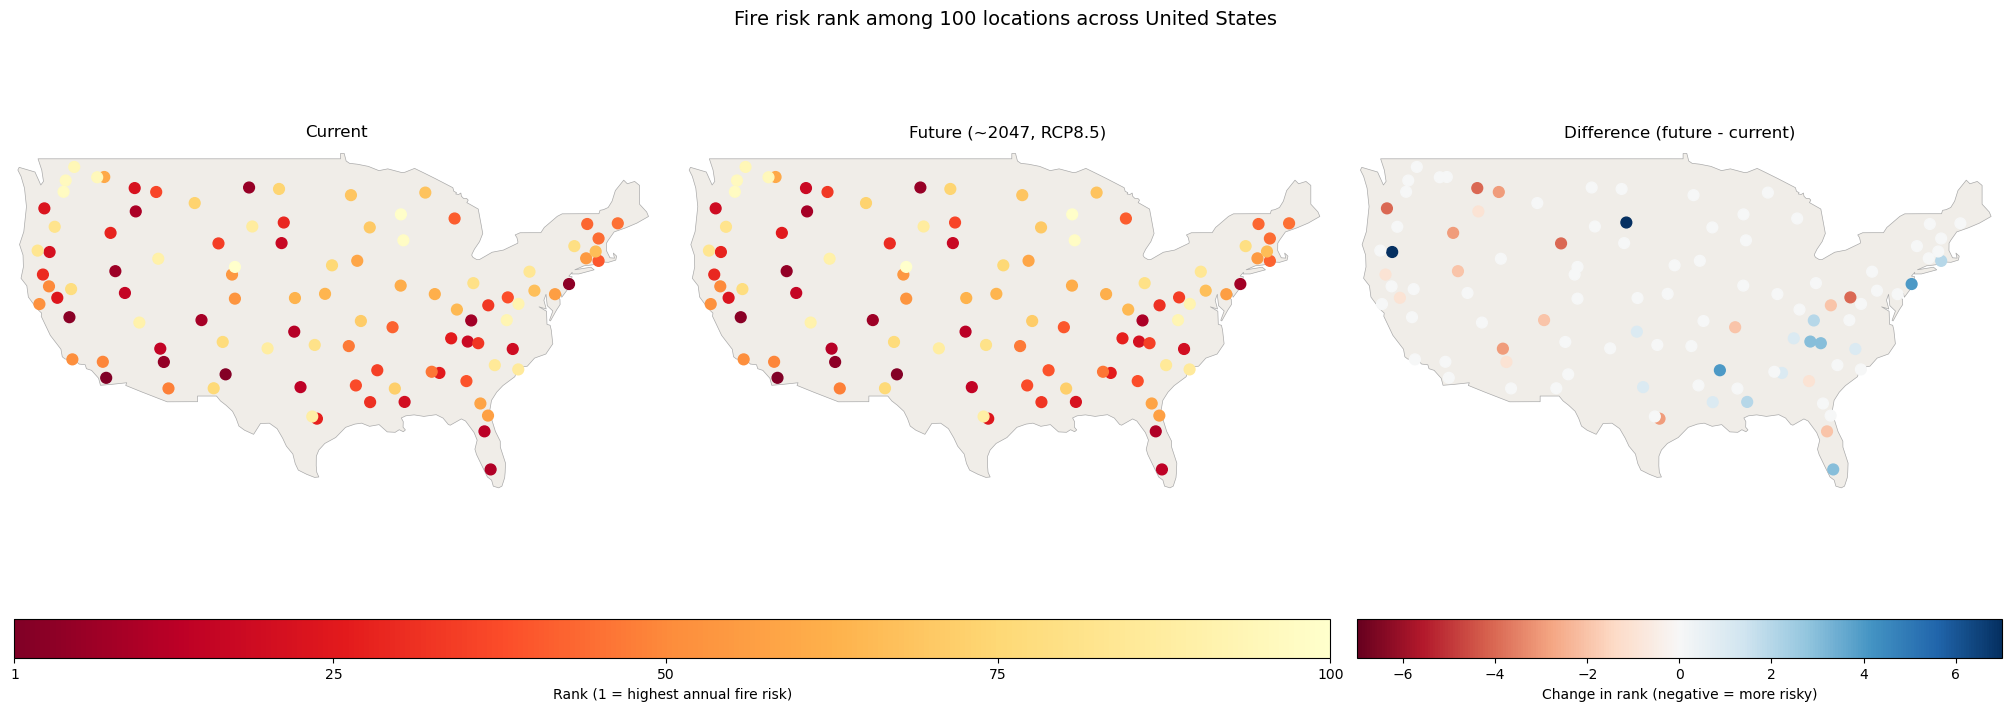

In [9]:
n_points = len(gdf)

plot_three_panel_maps(
    gdf=gdf,
    conus=conus,
    present_col='present_rank',
    future_col='future_rank',
    diff_col='rank_change',
    suptitle='Fire risk rank among 100 locations across United States',
    seq_cmap='YlOrRd_r',
    diff_cmap='RdBu',
    seq_label='Rank (1 = highest annual fire risk)',
    diff_label='Change in rank (negative = more risky)',
    seq_vmin=1.0,
    seq_vmax=float(n_points),
    seq_ticks=[1, 25, 50, 75, 100],
)